# Sistema de recomendación de libros con PCA

**Autor:** Arturo Vargas Espinosa

Este notebook entrena el modelo que usa la aplicación web [**Estantería**](app/). En la app, el usuario califica con estrellas (de ½ a 5) los libros que ha leído y recibe recomendaciones personalizadas.

La idea central es aplicar **Análisis de Componentes Principales (PCA)** a la matriz usuario × libro:

1. Cada lector es un vector con sus calificaciones de 10,000 libros.
2. PCA encuentra unas pocas direcciones (*componentes*) que resumen la mayor parte de la variación en los gustos de los lectores: "ejes de gusto".
3. Cada libro queda descrito por sus **cargas** en esos ejes. Un usuario nuevo se **proyecta** sobre los componentes y su fila se **reconstruye** para estimar qué tanto le gustaría cada libro.

Como GitHub Pages solo sirve archivos estáticos, el entrenamiento se hace aquí una sola vez y se exportan las cargas; la proyección y la reconstrucción (dos multiplicaciones de matrices) se hacen en JavaScript dentro del navegador.

## 1. Importar los datos

Se usa el dataset **goodbooks-10k** (Zając, 2017): calificaciones de 1 a 5 estrellas de usuarios de Goodreads para los 10,000 libros más populares del sitio.

- `ratings.csv`: una fila por calificación (`user_id`, `book_id`, `rating`).
- `books.csv`: metadatos de cada libro (título, autores, año, portada, promedio, etc.).

In [1]:
import json
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
from sklearn.decomposition import TruncatedSVD

SEED = 42
plt.rcParams['figure.dpi'] = 110

ratings = pd.read_csv('Datos/ratings.csv')
books = pd.read_csv('Datos/books.csv')
ratings.head()

,user_id,book_id,rating
0,1,258,5
1,2,4081,4
2,2,260,5
3,2,9296,5
4,2,2318,3


In [2]:
books[['book_id', 'title', 'authors', 'original_publication_year', 'average_rating', 'ratings_count']].head()

,book_id,title,authors,original_publication_year,average_rating,ratings_count
0,1,"The Hunger Games (The Hunger Games, #1)",Suzanne Collins,2008.0,4.34,4780653
1,2,Harry Potter and the Sorcerer's Stone (Harry P...,"J.K. Rowling, Mary GrandPré",1997.0,4.44,4602479
2,3,"Twilight (Twilight, #1)",Stephenie Meyer,2005.0,3.57,3866839
3,4,To Kill a Mockingbird,Harper Lee,1960.0,4.25,3198671
4,5,The Great Gatsby,F. Scott Fitzgerald,1925.0,3.89,2683664


## 2. Revisar características

### Tamaño

In [3]:
n_usuarios = ratings['user_id'].nunique()
n_libros = ratings['book_id'].nunique()
print(f"Calificaciones: {len(ratings):,}")
print(f"Usuarios: {n_usuarios:,}")
print(f"Libros con calificaciones: {n_libros:,}")
print(f"Densidad de la matriz usuario × libro: {len(ratings) / (n_usuarios * n_libros):.2%}")

Calificaciones: 5,976,479
Usuarios: 53,424
Libros con calificaciones: 10,000
Densidad de la matriz usuario × libro: 1.12%


Solo ~1% de las celdas de la matriz tiene calificación. Si se guardara completa (53 mil × 10 mil) serían 534 millones de celdas, casi todas vacías; por eso se trabajará con una **matriz dispersa**, que solo guarda las celdas con dato.

### Huecos y duplicados

In [4]:
print("Nulos en ratings:", ratings.isna().sum().sum())
print("Pares usuario-libro duplicados:", ratings.duplicated(['user_id', 'book_id']).sum())
print("\nNulos en books (solo columnas con nulos):")
print(books.isna().sum()[books.isna().sum() > 0])

Nulos en ratings: 0


Pares usuario-libro duplicados: 0

Nulos en books (solo columnas con nulos):
isbn                          700
isbn13                        585
original_publication_year      21
original_title                585
language_code                1084
dtype: int64


Las calificaciones están completas y sin duplicados. Los nulos de `books` (ISBN, año, idioma) solo afectan lo que se muestra en la app, no al modelo.

### Distribución de las calificaciones

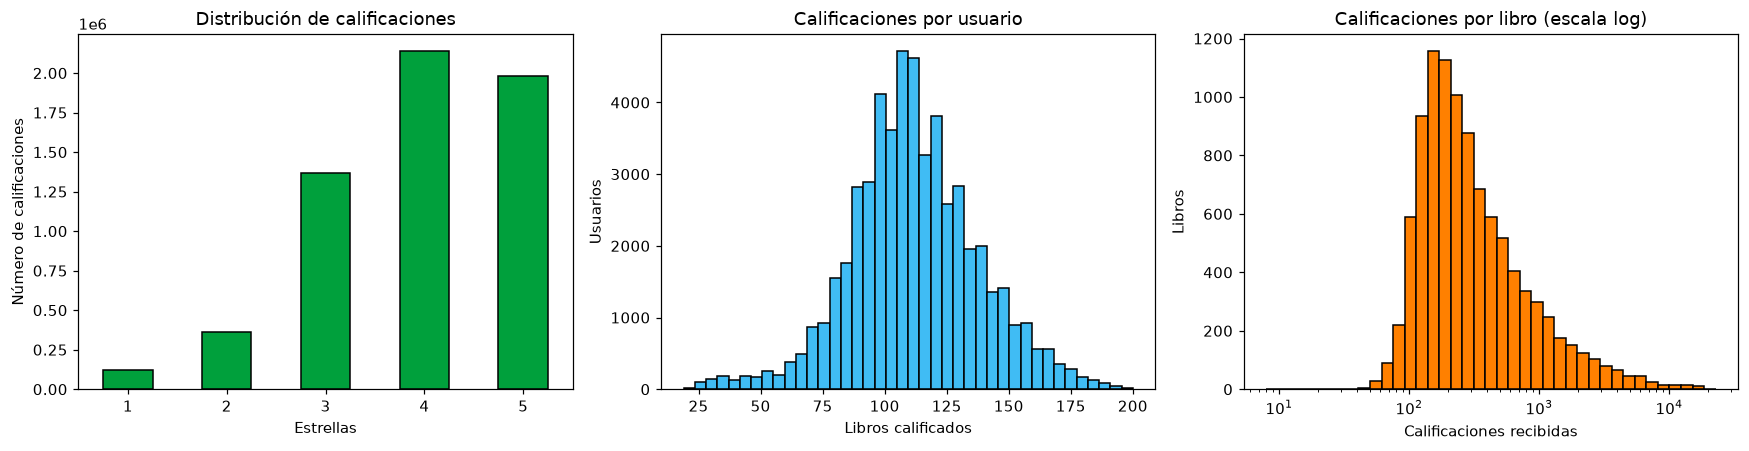

rating
1    0.021
2    0.060
3    0.229
4    0.358
5    0.332
Name: proportion, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

ratings['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='#00a03c', edgecolor='black', rot=0)
axes[0].set_title('Distribución de calificaciones')
axes[0].set_xlabel('Estrellas'); axes[0].set_ylabel('Número de calificaciones')

por_usuario = ratings.groupby('user_id').size()
axes[1].hist(por_usuario, bins=40, color='#40bcf4', edgecolor='black')
axes[1].set_title('Calificaciones por usuario')
axes[1].set_xlabel('Libros calificados'); axes[1].set_ylabel('Usuarios')

por_libro = ratings.groupby('book_id').size()
axes[2].hist(por_libro, bins=np.logspace(np.log10(por_libro.min()), np.log10(por_libro.max()), 40), color='#ff8000', edgecolor='black')
axes[2].set_xscale('log')
axes[2].set_title('Calificaciones por libro (escala log)')
axes[2].set_xlabel('Calificaciones recibidas'); axes[2].set_ylabel('Libros')

plt.tight_layout(); plt.show()

print(ratings['rating'].value_counts(normalize=True).sort_index().round(3))

- Las calificaciones están cargadas hacia lo positivo: 4 y 5 estrellas suman ~69%. La gente tiende a calificar libros que eligió leer.
- Cada usuario calificó entre 19 y 200 libros (mediana ~111), así que todos tienen suficiente historial.
- La popularidad de los libros es muy desigual (cola larga): unos cuantos títulos acumulan decenas de miles de calificaciones y la mayoría tiene unos cientos. Esto importa porque un recomendador ingenuo tiende a recomendar siempre los mismos *bestsellers*.

## 3. Separar usuarios de entrenamiento y de prueba

En la app, el usuario es **nuevo**: el modelo nunca vio sus calificaciones. Para evaluar de forma honesta se reproduce esa situación: se apartan 2,000 usuarios completos que **no se usan para entrenar** el PCA. Después se simulará que cada uno de ellos usa la app.

In [6]:
rng = np.random.default_rng(SEED)
usuarios_prueba = rng.choice(ratings['user_id'].unique(), size=2000, replace=False)
es_prueba = ratings['user_id'].isin(usuarios_prueba)

train = ratings[~es_prueba].copy()
test = ratings[es_prueba].copy()
print(f"Entrenamiento: {train['user_id'].nunique():,} usuarios, {len(train):,} calificaciones")
print(f"Prueba:        {test['user_id'].nunique():,} usuarios, {len(test):,} calificaciones")

Entrenamiento: 51,424 usuarios, 5,751,370 calificaciones
Prueba:        2,000 usuarios, 225,109 calificaciones


## 4. Matriz usuario × libro y centrado

PCA trabaja con datos **centrados**: busca direcciones de máxima varianza alrededor de un punto de referencia. En una matriz de calificaciones hay un problema extra: las celdas vacías. En una matriz dispersa una celda vacía vale 0, así que hay que elegir qué significa ese 0.

Se comparan dos formas de centrar:

| Centrado | Fórmula | Qué significa una celda vacía (0) |
|---|---|---|
| **Por usuario** (como en MovieLens en clase) | $\tilde r_{ui} = r_{ui} - \bar r_u$ | "Calificación igual a su promedio" |
| **En el punto neutro de la escala** | $\tilde r_{ui} = r_{ui} - 3$ | "Sin opinión": ni le gustó ni le disgustó |

Con el centrado por usuario, un lector que pone puros 4 y 5 queda con valores cercanos a 0 en todo: se pierde la información de **qué libros eligió leer**, que es la señal más fuerte del dataset. Con el centrado en 3, un 5 queda en +2, un 1 en −2, y haber leído y disfrutado un libro sí deja huella. Además coincide con lo que captura la app: un libro calificado con $e$ estrellas entra al perfil como $e - 3$, y un libro sin calificar como 0.

La comparación con datos se hace en la sección 7.

In [7]:
idx_usuario = {u: i for i, u in enumerate(train['user_id'].unique())}
filas = train['user_id'].map(idx_usuario).to_numpy()
cols = train['book_id'].to_numpy() - 1          # book_id va de 1 a 10,000 -> columna 0 a 9,999
N_LIBROS = len(books)

def matriz(valores):
    return sp.csr_matrix((np.asarray(valores, dtype=float), (filas, cols)), shape=(len(idx_usuario), N_LIBROS))

X_neutro = matriz(train['rating'] - 3)
X_usuario = matriz(train['rating'] - train.groupby('user_id')['rating'].transform('mean'))

print("Forma:", X_neutro.shape, f"| celdas con dato: {X_neutro.nnz:,}")
pd.DataFrame(X_neutro[:8, :10].toarray(), columns=books['title'].str[:18].iloc[:10]).astype(int)

Forma: (51424, 10000) | celdas con dato: 5,751,370


title,The Hunger Games (,Harry Potter and t,Twilight (Twilight,To Kill a Mockingb,The Great Gatsby,The Fault in Our S,The Hobbit,The Catcher in the,Angels & Demons (,Pride and Prejudic
0,0,0,0,2,0,0,0,0,0,1
1,0,2,0,0,2,0,0,1,0,2
2,0,2,0,1,1,0,1,1,0,2
3,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,-2
5,1,1,1,0,2,0,0,0,-2,2
6,0,0,0,0,0,0,0,2,0,0
7,0,1,2,0,1,0,0,2,0,2


Así se ve un pedazo de la matriz centrada en 3: casi todo es 0 (no leído) y los valores van de −2 a +2.

## 5. PCA con `TruncatedSVD`

`sklearn.decomposition.PCA` necesita la matriz densa (534 millones de celdas ≈ 4 GB), así que se usa `TruncatedSVD`, que calcula la misma descomposición en valores singulares directamente sobre la matriz dispersa:

$$X \approx U_k\,\Sigma_k\,V_k^\top$$

- Las filas de $V_k^\top$ son los **componentes principales**: cada una es un vector de 10,000 **cargas**, una por libro.
- $\Sigma_k$ (valores singulares) indica cuánta variación captura cada componente.
- $U_k\Sigma_k$ son las coordenadas (*scores*) de cada usuario en esos componentes.

Las columnas ya están centradas en el punto neutro, así que esto equivale a PCA sobre los datos centrados.

### ¿Cuántos componentes?

Primero se ajusta un modelo grande (200 componentes) para ver cómo se acumula la varianza explicada.

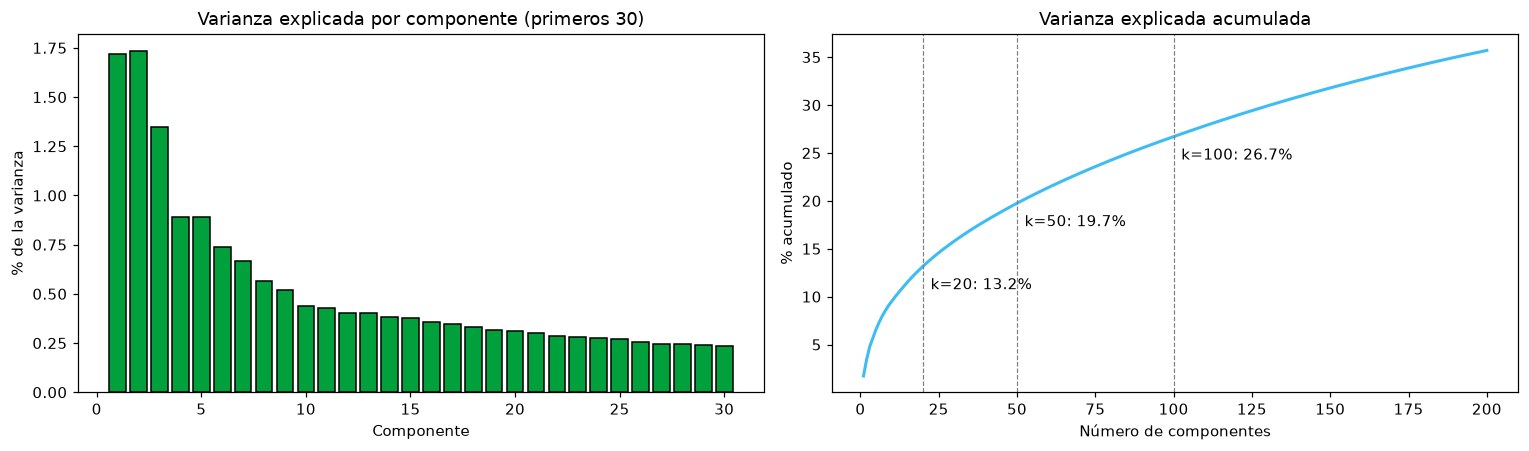

In [8]:
svd_200 = TruncatedSVD(n_components=200, random_state=SEED).fit(X_neutro)
var = svd_200.explained_variance_ratio_
acum = np.cumsum(var)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].bar(range(1, 31), var[:30] * 100, color='#00a03c', edgecolor='black')
axes[0].set_title('Varianza explicada por componente (primeros 30)')
axes[0].set_xlabel('Componente'); axes[0].set_ylabel('% de la varianza')

axes[1].plot(range(1, 201), acum * 100, color='#40bcf4', lw=2)
for k in (20, 50, 100):
    axes[1].axvline(k, color='gray', ls='--', lw=.8)
    axes[1].annotate(f'k={k}: {acum[k-1]:.1%}', (k, acum[k-1] * 100), xytext=(5, -15), textcoords='offset points')
axes[1].set_title('Varianza explicada acumulada')
axes[1].set_xlabel('Número de componentes'); axes[1].set_ylabel('% acumulado')
plt.tight_layout(); plt.show()

A diferencia de datasets "de libro de texto", aquí la varianza acumulada crece lento: los primeros tres componentes destacan (entre 1.3% y 1.7% cada uno), después la contribución cae rápido y con 50 componentes apenas se llega a ~20%. Es normal en matrices de calificaciones: los gustos son muy individuales y hay mucho ruido (cada lector leyó solo ~1% del catálogo).

Por eso **no se elige k por un umbral de varianza** (como "90%"), que aquí necesitaría miles de componentes. Se elige por lo que importa: **qué tan buenas son las recomendaciones** en los usuarios de prueba (sección 7). Antes se interpretan los componentes.

## 6. Interpretar las cargas

Cada componente asigna una carga a cada libro. Los libros con cargas grandes del mismo signo **suelen gustarle a los mismos lectores**, y los de signo contrario a lectores distintos. Para que la interpretación sea legible se miran solo los 2,000 libros más populares.

In [9]:
K = 50
svd = TruncatedSVD(n_components=K, random_state=SEED).fit(X_neutro)
V = svd.components_                      # k × 10,000: cargas de cada libro
s = svd.singular_values_
print(f"Varianza explicada con k={K}: {svd.explained_variance_ratio_.sum():.1%}")

books['titulo_corto'] = books['title'].str.replace(r'\s*\(.*#.*\)$', '', regex=True).str[:45]
populares = books.nlargest(2000, 'ratings_count').index.to_numpy()   # índice = book_id - 1

def extremos(c, n=6):
    cargas = pd.Series(V[c, populares], index=populares)
    pos = cargas.nlargest(n).index
    neg = cargas.nsmallest(n).index
    return pd.DataFrame({
        f'(+) libros': books.loc[pos, 'titulo_corto'].values,
        f'(+) carga': cargas[pos].round(3).values,
        f'(−) libros': books.loc[neg, 'titulo_corto'].values,
        f'(−) carga': cargas[neg].round(3).values,
    })

for c in range(4):
    print(f"\n=== Componente {c + 1} ({svd.explained_variance_ratio_[c]:.2%} de la varianza) ===")
    display(extremos(c))

Varianza explicada con k=50: 19.7%

=== Componente 1 (1.72% de la varianza) ===


,(+) libros,(+) carga,(−) libros,(−) carga
0,Harry Potter and the Sorcerer's Stone,0.229,The 3 Mistakes of My Life,-0.001
1,The Hunger Games,0.203,2 States: The Story of My Marriage,0.000
2,Harry Potter and the Deathly Hallows,0.189,The Mermaid Chair,0.000
3,Harry Potter and the Prisoner of Azkaban,0.185,The Jane Austen Book Club,0.000
4,Harry Potter and the Goblet of Fire,0.183,Five Point Someone,0.000
5,Harry Potter and the Half-Blood Prince,0.180,الفيل الأزرق,0.000



=== Componente 2 (1.73% de la varianza) ===


,(+) libros,(+) carga,(−) libros,(−) carga
0,Harry Potter and the Deathly Hallows,0.230,To Kill a Mockingbird,-0.138
1,Harry Potter and the Goblet of Fire,0.228,1984,-0.115
2,Harry Potter and the Half-Blood Prince,0.228,The Catcher in the Rye,-0.106
3,Harry Potter and the Prisoner of Azkaban,0.225,Animal Farm,-0.103
4,Harry Potter and the Order of the Phoenix,0.219,The Great Gatsby,-0.099
5,Harry Potter and the Chamber of Secrets,0.212,Of Mice and Men,-0.099



=== Componente 3 (1.35% de la varianza) ===


,(+) libros,(+) carga,(−) libros,(−) carga
0,The Help,0.214,The Fellowship of the Ring,-0.159
1,The Hunger Games,0.163,The Hobbit,-0.158
2,Twilight,0.162,The Hitchhiker's Guide to the Galaxy,-0.127
3,Water for Elephants,0.126,The Return of the King,-0.117
4,The Kite Runner,0.123,The Two Towers,-0.113
5,The Fault in Our Stars,0.112,1984,-0.112



=== Componente 4 (0.89% de la varianza) ===


,(+) libros,(+) carga,(−) libros,(−) carga
0,A Game of Thrones,0.204,Charlotte's Web,-0.121
1,A Storm of Swords,0.154,Harry Potter and the Prisoner of Azkaban,-0.116
2,A Clash of Kings,0.151,The Giving Tree,-0.112
3,The Girl with the Dragon Tattoo,0.137,Harry Potter and the Goblet of Fire,-0.112
4,The Hunger Games,0.124,Where the Sidewalk Ends,-0.111
5,A Dance with Dragons,0.111,Harry Potter and the Chamber of Secrets,-0.108


Cómo leer las tablas:

- **Componente 1 — "popularidad"**: todas sus cargas importantes son positivas y corresponden a los libros más leídos (*Harry Potter*, *The Hunger Games*); el extremo negativo prácticamente vale 0. No separa gustos: mide qué tanto leyó y disfrutó alguien los grandes éxitos.
- **Componente 2 — "Harry Potter vs. lecturas escolares"**: de un lado toda la saga de *Harry Potter*; del otro, los clásicos que se leen en la escuela (*To Kill a Mockingbird*, *1984*, *The Catcher in the Rye*, *Animal Farm*).
- **Componente 3 — "ficción contemporánea vs. fantasía y ciencia ficción clásicas"**: *The Help*, *Twilight*, *Water for Elephants*, *The Kite Runner* contra Tolkien, *The Hitchhiker's Guide to the Galaxy* y *1984*.
- **Componente 4 — "adulto vs. infantil"**: *A Game of Thrones* y *The Girl with the Dragon Tattoo* contra *Charlotte's Web*, *The Giving Tree* y los primeros *Harry Potter*.

Sin que nadie le diga qué es un género, PCA descubre estos "ejes de gusto" solo a partir de quién calificó qué. Son los ejes que la app usa para ubicar al lector.

La app muestra estos mismos extremos con portadas en la sección **"¿Cómo funciona?"**.

### Visualización: libros en los componentes 2 y 3

Se grafica cada libro popular según sus cargas en los componentes 2 y 3 (el 1 casi solo mide popularidad). Los libros cercanos en el plano tienden a gustarle a los mismos lectores.

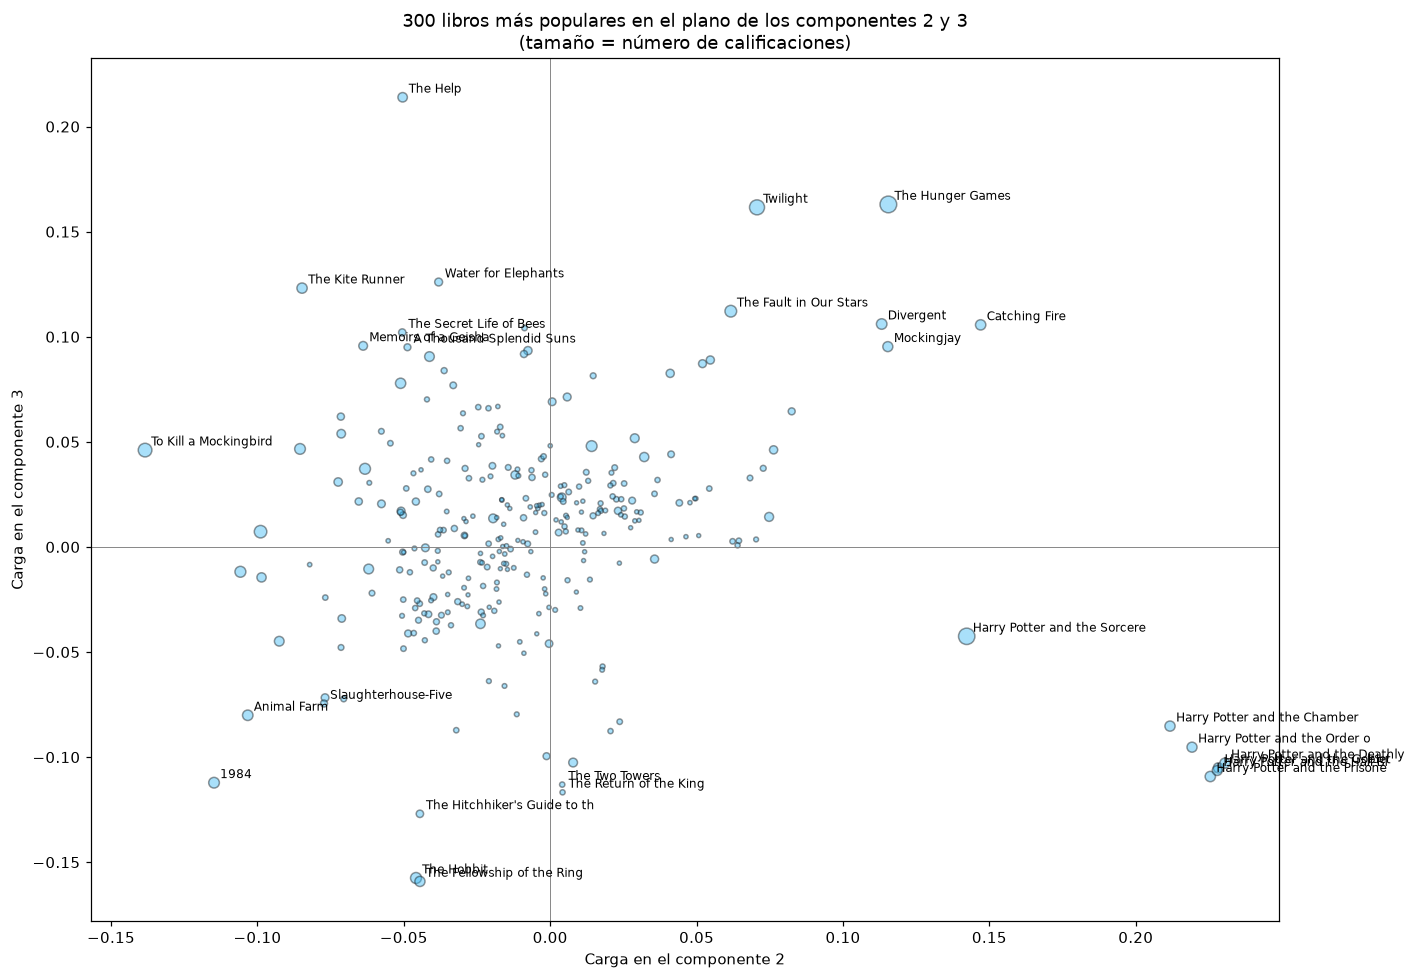

In [10]:
top300 = books.nlargest(300, 'ratings_count').index.to_numpy()
x, y = V[1, top300], V[2, top300]

fig, ax = plt.subplots(figsize=(13, 9))
ax.scatter(x, y, s=books.loc[top300, 'ratings_count'] / 4e4, alpha=.45, color='#40bcf4', edgecolor='#14181c')
ax.axhline(0, color='gray', lw=.6); ax.axvline(0, color='gray', lw=.6)

# Etiquetar los libros más extremos en cada dirección
dist = np.hypot(x, y)
for j in np.argsort(-dist)[:28]:
    ax.annotate(books.loc[top300[j], 'titulo_corto'][:28], (x[j], y[j]), fontsize=8,
                xytext=(4, 3), textcoords='offset points')
ax.set_xlabel('Carga en el componente 2'); ax.set_ylabel('Carga en el componente 3')
ax.set_title('300 libros más populares en el plano de los componentes 2 y 3\n(tamaño = número de calificaciones)')
plt.tight_layout(); plt.show()

Se forman cuatro zonas reconocibles: abajo a la derecha toda la saga de *Harry Potter*; arriba a la derecha las sagas juveniles (*The Hunger Games*, *Twilight*, *Divergent*); arriba a la izquierda la ficción contemporánea para adultos (*The Help*, *The Kite Runner*); y abajo a la izquierda los clásicos y la fantasía y ciencia ficción clásicas (*1984*, *Animal Farm*, Tolkien). Esa cercanía es justo lo que usa la sección **"Libros parecidos"** de la app.

## 7. Recomendar a un usuario nuevo: proyección y reconstrucción

Un usuario nuevo llega con un vector $r$ de 10,000 entradas: estrellas − 3 en los libros que calificó (de −2.5 a +2) y 0 en el resto. Con PCA:

1. **Proyección**: su posición en los $k$ ejes de gusto es $z = V_k\,r$ (un vector de $k$ números).
2. **Reconstrucción**: su fila estimada es $\hat r = V_k^\top z$. Cada entrada $\hat r_j = z\cdot v_j$ dice qué tanto le debería gustar el libro $j$.
3. Se recomiendan los libros no marcados con mayor $\hat r_j$.

### Evaluación

Para cada uno de los 2,000 usuarios de prueba se simula el uso de la app:

- Se toman **15 de sus calificaciones** (sin contar los 3, que son neutrales). y se convierten a +1 si le gustó (4–5 estrellas) o −1 si no (1–2). Es la versión más simple de la entrada; en la app las estrellas además indican cuánto le gustó.
- Con eso se generan sus **20 recomendaciones**.
- Se mide la **precisión@20**: qué fracción de esas 20 recomendaciones son libros que el usuario **sí leyó y calificó con 4 o 5** (entre las calificaciones que no se le dieron al modelo).

Como referencia (*baseline*) se recomiendan simplemente los 20 libros más populares que el usuario no marcó. Si PCA no le gana a eso, no está personalizando nada.

In [11]:
test = test.sample(frac=1, random_state=SEED)
no_neutras = test[test['rating'] != 3].copy()
entrada = no_neutras[no_neutras.groupby('user_id').cumcount() < 15]

idx_prueba = {u: i for i, u in enumerate(usuarios_prueba)}
R = sp.csr_matrix((np.where(entrada['rating'] >= 4, 1.0, -1.0),
                   (entrada['user_id'].map(idx_prueba), entrada['book_id'] - 1)),
                  shape=(len(idx_prueba), N_LIBROS))
ya_marcados = R.toarray() != 0

resto = test.merge(entrada[['user_id', 'book_id']], how='left', indicator=True)
gustados = resto[(resto['_merge'] == 'left_only') & (resto['rating'] >= 4)]
objetivo = np.zeros((len(idx_prueba), N_LIBROS), dtype=bool)
objetivo[gustados['user_id'].map(idx_prueba), gustados['book_id'] - 1] = True

def precision_at(puntajes, n=20):
    p = np.array(puntajes, dtype=float, copy=True)
    p[ya_marcados] = -np.inf
    top = np.argpartition(-p, n, axis=1)[:, :n]
    return np.take_along_axis(objetivo, top, axis=1).mean()

popularidad = np.bincount(cols, minlength=N_LIBROS).astype(float)
prec_pop = precision_at(np.tile(popularidad, (len(idx_prueba), 1)))
print(f"Baseline (más populares): precisión@20 = {prec_pop:.3f}")

Baseline (más populares): precisión@20 = 0.201


In [12]:
resultados = []
for nombre, X in [('Centrado por usuario', X_usuario), ('Centrado en 3', X_neutro)]:
    for k in (10, 20, 50, 100, 200):
        Vk = TruncatedSVD(n_components=k, random_state=SEED).fit(X).components_
        resultados.append({'centrado': nombre, 'k': k, 'precision@20': precision_at((R @ Vk.T) @ Vk)})
resultados = pd.DataFrame(resultados)
resultados.pivot(index='k', columns='centrado', values='precision@20').round(3)

centrado,Centrado en 3,Centrado por usuario
k,,
10,0.302,0.238
20,0.326,0.239
50,0.341,0.231
100,0.336,0.241
200,0.323,0.226


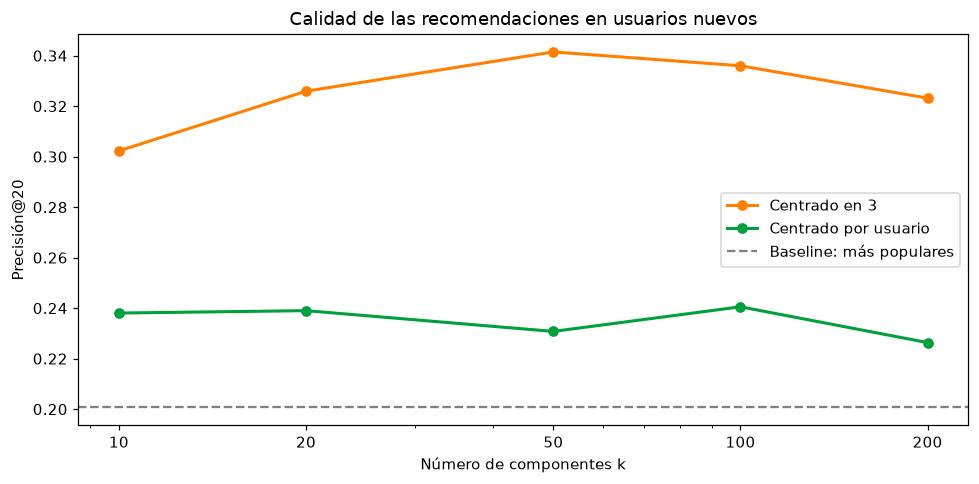

In [13]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for (nombre, g), color in zip(resultados.groupby('centrado'), ['#ff8000', '#00a03c']):
    ax.plot(g['k'], g['precision@20'], marker='o', lw=2, color=color, label=nombre)
ax.axhline(prec_pop, color='gray', ls='--', label='Baseline: más populares')
ax.set_xscale('log'); ax.set_xticks([10, 20, 50, 100, 200]); ax.set_xticklabels([10, 20, 50, 100, 200])
ax.set_xlabel('Número de componentes k'); ax.set_ylabel('Precisión@20')
ax.set_title('Calidad de las recomendaciones en usuarios nuevos')
ax.legend(); plt.tight_layout(); plt.show()

Conclusiones de la evaluación:

- **El centrado por usuario apenas le gana a la popularidad.** Como se explicó en la sección 4, borra la señal de "qué decidió leer" cada persona.
- **El centrado en 3 mejora la precisión en ~70% respecto al baseline**: alrededor de un tercio de las 20 recomendaciones son libros que el usuario realmente leyó y le gustaron, con solo 15 libros de entrada. Hay que considerar que es una cota inferior: una recomendación "fallida" puede ser un libro que le gustaría pero que todavía no ha leído.
- **Más componentes no siempre es mejor.** De 10 a 50 la precisión sube porque el modelo distingue más matices de gusto; arriba de ~50 se estanca o baja, porque los componentes extra empiezan a capturar ruido de usuarios particulares (sobreajuste). Se elige **k = 50** para la app.

In [14]:
mejor = resultados[(resultados['centrado'] == 'Centrado en 3') & (resultados['k'] == K)]['precision@20'].item()
print(f"Modelo elegido: centrado en 3, k={K} -> precisión@20 = {mejor:.3f} (baseline {prec_pop:.3f}, mejora de {mejor / prec_pop - 1:.0%})")

Modelo elegido: centrado en 3, k=50 -> precisión@20 = 0.341 (baseline 0.201, mejora de 70%)


## 8. Ejemplo: un lector nuevo

Se simula a alguien que califica en la app algunos libros de fantasía y juveniles con muchas estrellas y un par de clásicos con pocas.

In [15]:
def buscar(titulo):
    return books.index[books['title'].str.contains(titulo, case=False, regex=False)][0]

estrellas_usuario = {
    buscar("Harry Potter and the Sorcerer's Stone"): 5,
    buscar('The Hunger Games (The Hunger Games, #1)'): 4.5,
    buscar('The Hobbit'): 4,
    buscar('Divergent (Divergent, #1)'): 4,
    buscar('Pride and Prejudice'): 1.5,
    buscar('Wuthering Heights'): 2,
}
for j, e in estrellas_usuario.items():
    print(f"{'★' * int(e)}{'½' if e % 1 else ''}".ljust(6), books.loc[j, 'title'])

gustos = {j: e - 3 for j, e in estrellas_usuario.items()}   # estrellas − 3, igual que en la app

def recomendar(gustos, n=12):
    r = np.zeros(N_LIBROS)
    for j, v in gustos.items():
        r[j] = v
    z = V @ r                    # proyección: posición del usuario en los k ejes
    puntaje = V.T @ z            # reconstrucción de su fila
    puntaje[list(gustos)] = -np.inf
    top = np.argsort(-puntaje)[:n]
    return pd.DataFrame({'libro': books.loc[top, 'title'].values,
                         'autor': books.loc[top, 'authors'].str.split(',').str[0].values,
                         'puntaje': (puntaje[top] / puntaje[top].max()).round(2)})

recomendar(gustos)

★★★★★  Harry Potter and the Sorcerer's Stone (Harry Potter, #1)
★★★★½  The Hunger Games (The Hunger Games, #1)
★★★★   The Hobbit
★★★★   Divergent (Divergent, #1)
★½     Pride and Prejudice
★★     Wuthering Heights


,libro,autor,puntaje
0,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,1.00
1,"Catching Fire (The Hunger Games, #2)",Suzanne Collins,0.58
2,"The Lion, the Witch, and the Wardrobe (Chronic...",C.S. Lewis,0.58
3,"Insurgent (Divergent, #2)",Veronica Roth,0.46
4,"A Game of Thrones (A Song of Ice and Fire, #1)",George R.R. Martin,0.45
5,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,0.39
6,The Lightning Thief (Percy Jackson and the Oly...,Rick Riordan,0.38
7,"Mockingjay (The Hunger Games, #3)",Suzanne Collins,0.36
8,"Eragon (The Inheritance Cycle, #1)",Christopher Paolini,0.33
9,"Fifty Shades of Grey (Fifty Shades, #1)",E.L. James,0.25


Las recomendaciones son coherentes con el perfil: continuaciones de las sagas que le gustaron y otros libros de fantasía y distopía juvenil, sin clásicos románticos.

### Libros parecidos

Para la página de cada libro, la app usa la **similitud coseno** entre las cargas de dos libros, ponderadas por los valores singulares (los componentes que explican más varianza pesan más):

$$\text{sim}(i,j) = \frac{(\Sigma v_i)\cdot(\Sigma v_j)}{\lVert\Sigma v_i\rVert\,\lVert\Sigma v_j\rVert}$$

In [16]:
E = (V * s[:, None]).T                     # 10,000 × k
normas = np.linalg.norm(E, axis=1)
E_unit = E / normas[:, None]
confianza = np.sqrt(np.minimum(1, normas / np.median(normas)))   # igual que en la app

def parecidos(titulo, n=8):
    i = buscar(titulo)
    sim = (E_unit @ E_unit[i]) * confianza
    sim[i] = -np.inf
    top = np.argsort(-sim)[:n]
    return pd.DataFrame({'libro': books.loc[top, 'title'].values, 'similitud': sim[top].round(3)})

print('Parecidos a "The Da Vinci Code":')
display(parecidos('The Da Vinci Code'))
print('Parecidos a "Pride and Prejudice":')
display(parecidos('Pride and Prejudice'))

Parecidos a "The Da Vinci Code":


,libro,similitud
0,"The Lost Symbol (Robert Langdon, #3)",0.937
1,"Angels & Demons (Robert Langdon, #1)",0.920
2,"Inferno (Robert Langdon, #4)",0.890
3,Digital Fortress,0.832
4,Deception Point,0.830
5,"If Tomorrow Comes (Tracy Whitney Series, #1)",0.661
6,"The Immortals of Meluha (Shiva Trilogy, #1)",0.655
7,The Secret of the Nagas (Shiva Trilogy #2),0.643


Parecidos a "Pride and Prejudice":


,libro,similitud
0,Sense and Sensibility,0.952
1,Emma,0.920
2,Persuasion,0.920
3,Jane Eyre,0.912
4,Mansfield Park,0.882
5,Northanger Abbey,0.867
6,North and South,0.836
7,The Tenant of Wildfell Hall,0.800


Los libros con muy pocas calificaciones tienen cargas pequeñas y ruidosas, así que su dirección no es confiable. El factor de `confianza` castiga un poco a los libros cuya norma está por debajo de la mediana para que no aparezcan como "parecidos" por casualidad.

## 9. Exportar el modelo para la app

Se exportan dos archivos a `app/datos/`:

- **`vectores.bin`**: las cargas $V_k$ (10,000 libros × 50 componentes). Para que el archivo sea ligero, cada componente se **cuantiza** a enteros de 8 bits (`int8`, de −127 a 127) con su propio factor de escala. Pasa de 4 MB (float64) a 500 KB.
- **`modelo.json`**: metadatos de los libros (título, autor, año, promedio, portada), valores singulares, escalas, listas de libros para el *onboarding* y resultados de la evaluación.

Primero se verifica que la cuantización no cambie las recomendaciones.

In [17]:
escala = np.abs(V).max(axis=1) / 127
V_q = np.round(V / escala[:, None]).astype(np.int8)
V_rec = V_q * escala[:, None]

err_rel = np.linalg.norm(V - V_rec) / np.linalg.norm(V)
prec_q = precision_at((R @ V_rec.T) @ V_rec)
print(f"Error relativo de cuantización: {err_rel:.2%}")
print(f"Precisión@20 con float64: {mejor:.4f} | con int8: {prec_q:.4f}")

Error relativo de cuantización: 5.32%
Precisión@20 con float64: 0.3415 | con int8: 0.3421


El error es pequeño y la precisión prácticamente no cambia.

### Libros para el *onboarding* ("Descubrir")

Al entrar a la app se le pregunta al usuario por varios libros, uno por uno. Si solo se le preguntara por los más populares, todos tendrían cargas parecidas (componente 1) y cada respuesta aportaría poca información nueva. Por eso, después de los dos libros más leídos, se eligen libros **conocidos** (top 400 en popularidad) que estén en los **extremos de distintos componentes**, alternando polos positivo y negativo, y con máximo un libro por autor para no preguntar por toda una saga. Además se evitan las secuelas (títulos con `#2`, `#3`, …): tiene más sentido preguntar por el primer libro de una serie.

In [18]:
conocidos = books.nlargest(400, 'ratings_count').index.to_numpy()
autor_principal = books['authors'].str.split(',').str[0]

descubrir, autores = [], set()
es_secuela = books['title'].str.contains(r'#(?:[2-9]|\d\d)', regex=True)
def agregar(j):
    if not es_secuela[j] and j not in descubrir and autor_principal[j] not in autores:
        descubrir.append(int(j)); autores.add(autor_principal[j])

for j in conocidos[:2]:                  # empezar con los 2 más conocidos (Hunger Games, Harry Potter)
    agregar(j)
for c in range(1, 16):                   # componentes 2..16 (el 1 es popularidad)
    cargas = pd.Series(V[c, conocidos], index=conocidos)
    for j in list(cargas.nlargest(3).index) + list(cargas.nsmallest(3).index):
        agregar(j)
for j in conocidos:                      # completar con populares
    agregar(j)

print(f"{len(descubrir)} libros para descubrir. Primeros 12:")
for j in descubrir[:12]:
    print(' -', books.loc[j, 'title'])

256 libros para descubrir. Primeros 12:
 - The Hunger Games (The Hunger Games, #1)
 - Harry Potter and the Sorcerer's Stone (Harry Potter, #1)
 - To Kill a Mockingbird
 - 1984
 - The Catcher in the Rye
 - The Help
 - Twilight (Twilight, #1)
 - The Fellowship of the Ring (The Lord of the Rings, #1)
 - The Hitchhiker's Guide to the Galaxy (Hitchhiker's Guide to the Galaxy, #1)
 - A Game of Thrones (A Song of Ice and Fire, #1)
 - Charlotte's Web
 - The Giving Tree


In [19]:
import os, re
os.makedirs('app/datos', exist_ok=True)

def portada(url):
    # 'https://images.gr-assets.com/books/1447303603m/2767052.jpg' -> '1447303603l/2767052' (versión grande)
    m = re.match(r'https://images\.gr-assets\.com/books/(\d+)m/(\d+)\.jpg', str(url))
    return f'{m.group(1)}l/{m.group(2)}' if m else None

def isbn10(x):
    x = str(x).strip()
    return x.zfill(10) if re.fullmatch(r'\d{9,10}|\d{9}X', x) else None

def anio(x):
    return int(x) if pd.notna(x) else None

libros = [[row.title, row.authors, anio(row.original_publication_year), round(float(row.average_rating), 2),
           int(row.ratings_count), portada(row.image_url), isbn10(row.isbn), int(row.goodreads_book_id)]
          for row in books.itertuples()]

componentes = []
for c in range(1, 7):                    # componentes 2..7 (el 1 solo mide popularidad)
    cargas = pd.Series(V[c, populares], index=populares)
    componentes.append({'c': c + 1, 'varianza': round(float(svd.explained_variance_ratio_[c]), 5), 'pos': [int(j) for j in cargas.nlargest(6).index],
                        'neg': [int(j) for j in cargas.nsmallest(6).index]})

modelo = {
    'k': K,
    'escala': escala.round(10).tolist(),
    'valores_singulares': s.round(4).tolist(),
    'varianza_total': round(float(svd.explained_variance_ratio_.sum()), 4),
    'n_calificaciones': int(len(ratings)), 'n_usuarios': int(n_usuarios),
    'densidad': round(len(ratings) / (n_usuarios * n_libros), 5),
    'evaluacion': {'pca': round(float(prec_q), 4), 'popularidad': round(float(prec_pop), 4)},
    'descubrir': descubrir,
    'populares': [int(j) for j in books.nlargest(200, 'ratings_count').index],
    'componentes': componentes,
    'libros': libros,
}
with open('app/datos/modelo.json', 'w', encoding='utf-8') as f:
    json.dump(modelo, f, ensure_ascii=False, separators=(',', ':'))
V_q.T.copy().tofile('app/datos/vectores.bin')          # fila = libro, columna = componente

for nombre in ('modelo.json', 'vectores.bin'):
    print(f"{nombre}: {os.path.getsize('app/datos/' + nombre) / 1e6:.2f} MB")
print(f"Libros sin portada de Goodreads (se intenta Open Library): {sum(l[5] is None for l in libros):,}")

modelo.json: 1.10 MB
vectores.bin: 0.50 MB
Libros sin portada de Goodreads (se intenta Open Library): 3,332


## 10. Conclusión

- **PCA como modelo de gustos.** La matriz de 53 mil lectores × 10 mil libros se resume en 50 componentes. El primero mide básicamente popularidad y los siguientes separan géneros y públicos, lo que da una interpretación clara a las cargas.
- **La forma de centrar importa más que el número de componentes.** Centrar en el punto neutro (3) conserva la información de qué libros eligió leer cada persona, y da ~50% más precisión que el centrado por usuario.
- **Recomendar a un usuario nuevo no requiere reentrenar:** basta proyectarlo sobre los componentes ($z = V_k r$) y reconstruir su fila ($\hat r = V_k^\top z$). Son dos multiplicaciones de matrices, lo bastante rápidas para hacerse en el navegador con cada clic.
- **Desempeño:** con solo 15 libros calificados, ~1 de cada 3 recomendaciones es un libro que el usuario efectivamente leyó y disfrutó, contra ~1 de cada 5 al recomendar lo más popular.

**Limitaciones**

- El catálogo son los 10,000 libros más populares de Goodreads hasta 2017, casi todos en inglés.
- Un lector con gustos poco comunes, o que solo califica 2 o 3 libros, recibirá recomendaciones cercanas a las populares (problema de *arranque en frío*).
- La evaluación solo puede premiar libros que el usuario ya leyó; no mide si una recomendación nueva le habría gustado.